# PISO algorithm implementation


## Modelo 

Solves the incompressible viscous Navier-Stokes equations.

Momentum Eq.: $\frac{\partial u}{\partial t} + (u.\nabla)u = -\frac{\nabla p}{\rho} + \nu \nabla^2u + f$

Incompressibility Eq.: $\nabla u = 0$


## Case: Lid Driven cavity

Equivalent to lid driven cavity case in openFoam.



## Algorithm

Implementation of the PISO algoritm, identical to the icoFoam solver from  openFoam minus the orthogonality correction. 

$$\bold{M}.u^{n} = u^{n-1}/\Delta t -\nabla p = \bold{S} \qquad (1) $$

$$\bold{H} = \bold{A}.u^{n} - \bold{S} \qquad (2)$$

$$\nabla^2p = \bold{A}\nabla . (\bold{A}^{-1}\bold{H}) \qquad (3)$$

$$u^{n} = \bold{A}^{-1}\bold{H} - \bold{A}^{-1}\nabla p \qquad (4)$$

The PISO algorithm consists of an interation of the steps 1 -> 2 -> 3 -> 4 -> 2 -> ... apllied for both u and v components of the velocity, wich are solved independently, for each time step until convergence, then proceding to the next step.



# Code:

### Imports

In [1]:
import numpy as np
from matplotlib import pyplot as plt

### Constants

In [2]:
N_CELLS_X = 30
N_CELLS_Y = 20
RUN_TIME = 1
KINEMATIC_VISCOSITY = 0.1
N_ITER_STEP = 150
TOLERANCE_ITER = 10**(-3)
DENSITY = 1.0
HORIZONTAL_VELOCITY_TOP = 1.0
CFL = 2

#Under-relaxation factors
ALPHA_P = 0.8
ALPHA_U = 0.8
ALPHA_V = 0.8

### Domain Definition

In [3]:
dx = 1/N_CELLS_X
dy = 1/N_CELLS_Y
dt = np.min([dx, dy]) * CFL / (HORIZONTAL_VELOCITY_TOP)
print(f"dt:{dt}")

# Linear spacing in points
x = np.linspace(0.0, 1, N_CELLS_X+1)
y = np.linspace(0.0, 1, N_CELLS_Y+1)

# Domain Coordinates
Y, X = np.meshgrid(y, x)

# Initiate field template matrices 
u_field = np.zeros_like(X)
v_field = np.zeros_like(X)
p_field = np.zeros_like(X)

print(f'Nodes:{N_CELLS_X*N_CELLS_Y}')


dt:0.06666666666666667
Nodes:600


### Mometum Equation Discretization

The obejctive is to turn the Navier-Stoke equation into matrix form to solve numerically. 

$$\frac{\partial u}{\partial t} + (u.\nabla)u = -\frac{\nabla p}{\rho} + \nu \nabla^2u + f \implies \bold{M}.u = \bold{S}$$


#### Discretization:

##### Time derivative:

The time derivative (${\partial u}/{\partial t}$) is discretized by a simple euler scheme, with the previous time step being known from the initial condition or the last iteration, contributing to the source term.

$${\partial u}/{\partial t} \approx \frac{u^{n}_{i,j} - u^{n-1}_{i,j}}{\Delta t}$$


##### Difussion term:

The difusion ($\nu \nabla^2u$) term can be discretized  with traditional finite diference scheme.

$$ \nabla^2u \approx \frac{u^{n}_{i+1,j} - 2u^{n}_{i,j} + u^{n}_{i-1,j}}{\Delta x^2} + \frac{u^{n}_{i,j+1} - 2u^{n}_{i,j} + u^{n}_{i,j-1}}{\Delta y^2}$$

##### Convective term:

The convective term is linearized by substituting the advecting velocity with the velocity from the previous iteration.

$$ (u.\nabla)\,u = u\frac{\partial u}{\partial x} + v\frac{\partial u}{\partial y} \approx u^{n-1}_{i,j} . \frac{u^{n}_{i+1,j} - u^{n}_{i-1,j}}{2\Delta x} + v^{n-1}_{i,j} . \frac{u^{n}_{i+1,j} - u^{n}_{i-1,j}}{2\Delta y}$$

The ideia is that as the iteratios within a time step progress the $u^{n-1}_{i,j}$ and $u^{n}_{i,j}$ get progressivelly closer. (Thats the idea at least)


### Matrix assembly

For each component u and v of the velocity the above discretizations are used to assemble the NS equation in matrix form.

In [4]:
def DerivativeMatrix(u_filed):
    N, M = u_filed.shape
    return np.eye(N*M, k= 0)/dt

def LaplacianMatrix(u_field):
    N, M  = u_field.shape
    laplacian = np.zeros(shape=(N*M, N*M))
    laplacian += np.eye(N*M, k= 0) * (-2 * (1/dx**2 + 1/dy**2))
    laplacian += np.eye(N*M, k= M) * (1/dx**2)
    laplacian += np.eye(N*M, k=-M) * (1/dx**2)
    laplacian += np.eye(N*M, k= 1) * (1/dy**2)
    laplacian += np.eye(N*M, k=-1) * (1/dy**2)
    return laplacian


def ConvectionMatrix(u_field, v_field):
    N, M  = u_field.shape
    u_vec = np.reshape(u_field, (N*M,))
    v_vec = np.reshape(v_field, (N*M,))
    convetion = np.zeros(shape=(N*M, N*M))
    convetion += np.diag( u_vec/dx) @ np.eye(N*M, k= M)
    convetion += np.diag(-u_vec/dx) @ np.eye(N*M, k= 0)
    convetion += np.diag( v_vec/dy) @ np.eye(N*M, k= 1)
    convetion += np.diag(-v_vec/dy) @ np.eye(N*M, k= 0)
    return convetion

def ApplyPressureBC(L, p_field):
    """Overwrite the boundary rows of a Laplacian operator with the pressure BCs:
       Neumann (zero-gradient) on the three walls, Dirichlet p=0 at the lid (pins p)."""
    N, M = p_field.shape
    i, j = np.divmod(np.arange(N*M), M)           # flat index -> (i,j)
    lid    =  j == M-1                            # top  (y max): Dirichlet p = 0
    bottom =  j == 0                              # bottom wall:  Neumann
    left   = (i == 0)   & (j > 0) & (j < M-1)     # left wall:    Neumann
    right  = (i == N-1) & (j > 0) & (j < M-1)     # right wall:   Neumann

    L = L.copy()
    L[lid | bottom | left | right, :] = 0.0       # clear boundary rows
    r = np.where(lid)[0];    L[r, r] = 1.0                    # p = 0
    r = np.where(bottom)[0]; L[r, r] = 1.0; L[r, r+1] = -1.0  # p = p[i,1]
    r = np.where(left)[0];   L[r, r] = 1.0; L[r, r+M] = -1.0  # p = p[1,j]
    r = np.where(right)[0];  L[r, r] = 1.0; L[r, r-M] = -1.0  # p = p[N-2,j]
    return L

### Algortihm execution


In [5]:
# Initial values
t=0
u_field_previous = u_field.copy()
v_field_previous = v_field.copy()
p_field_previous = p_field.copy()

# Outer Time loop
while t < RUN_TIME:
    iter_step = 0
    print(f"Time:{t} s")

    # Calculate gradient of presuure
    dpdx, dpdy = np.gradient(p_field_previous, x, y)

    # (Eq. 1) Momentum Eq. Matrix Form X direction
    Mu = (
        DerivativeMatrix(u_field_previous) 
        + ConvectionMatrix(u_field_previous, v_field_previous) 
        - KINEMATIC_VISCOSITY * LaplacianMatrix(u_field_previous)
    )
    Su = np.reshape(u_field_previous/dt - dpdx/DENSITY, shape=((N_CELLS_X + 1)*(N_CELLS_Y + 1),))
    u_tilde_next = np.linalg.solve(Mu, Su)

    # (Eq. 1) Momentum Eq. Matrix Form Y direction
    Mv = (
        DerivativeMatrix(v_field_previous) 
        + ConvectionMatrix(u_field_previous, v_field_previous) 
        - KINEMATIC_VISCOSITY * LaplacianMatrix(v_field_previous)
    )
    Sv = np.reshape(v_field_previous/dt - dpdy/DENSITY, shape=((N_CELLS_X + 1)*(N_CELLS_Y + 1),))
    v_tilde_next = np.linalg.solve(Mv, Sv)
    
    conv_criteria = False
    u_next = u_tilde_next.copy()
    v_next = v_tilde_next.copy()
    p_next = np.reshape(p_field_previous, shape = ((N_CELLS_X + 1)*(N_CELLS_Y + 1),))

    # Pre-compute constant values
    Au = np.diag(np.diag(Mu))
    Au_inv = np.diag(1/np.diag(Mu))
    Av = np.diag(np.diag(Mv))
    Av_inv = np.diag(1/np.diag(Mv))
    L = LaplacianMatrix(p_field_previous)
    L_with_bondaries = ApplyPressureBC(L, p_field_previous)
    # Linear iterations
    while iter_step < N_ITER_STEP and not conv_criteria:
        iter_step+=1
        # Saves previous state to evaluate convergence
        u_old = u_next.copy()
        v_old = v_next.copy()
        p_old = p_next.copy()

        # (Eq. 2) Calculate soure term gradient in x direction
        u_prev_flat = np.reshape(u_field_previous, ((N_CELLS_X+1)*(N_CELLS_Y+1),))
        Hu = u_prev_flat/dt - (Mu - Au) @ u_next
        AHu_field = np.reshape(Au_inv @ Hu, shape = ((N_CELLS_X + 1),(N_CELLS_Y + 1)))
        dAHudx_field, _ = np.gradient((AHu_field), x, y)
        dAHudx_field[0,:] = dAHudx_field[-1,:] = 0.0
        dAHudx_field[:,0] = dAHudx_field[:,-1] = 0.0
        dAHudx = np.reshape(dAHudx_field, shape=((N_CELLS_X + 1)*(N_CELLS_Y + 1),))

        # (Eq. 2) Calculate soure term gradient in y direction
        v_prev_flat = np.reshape(v_field_previous, ((N_CELLS_X+1)*(N_CELLS_Y+1),))
        Hv = v_prev_flat/dt - (Mv - Av) @ v_next
        AHv_field = np.reshape(Av_inv @ Hv, shape = ((N_CELLS_X + 1),(N_CELLS_Y + 1)))
        _, dAHvdy_field = np.gradient(AHv_field, x, y)
        dAHvdy_field[0,:] = dAHvdy_field[-1,:] = 0.0
        dAHvdy_field[:,0] = dAHvdy_field[:,-1] = 0.0
        dAHvdy = np.reshape(dAHvdy_field, shape=((N_CELLS_X + 1)*(N_CELLS_Y + 1),))
        
        # (Eq. 3) Solves Laplace equation for Pressure
        p_next = np.linalg.solve(L_with_bondaries, Au @ dAHudx + Av @ dAHvdy)
        # Under-relaxation on P
        p_field_next = np.reshape(p_old + ALPHA_P *(p_next - p_old), shape=((N_CELLS_X+1),(N_CELLS_Y+1)))
        dpdx_field_next, dpdy_field_next = np.gradient(p_field_next, x, y)

        # (Eq. 4) Find the corrected velocity U
        u_next = Au_inv @ Hu - Au_inv @ np.reshape(dpdx_field_next, shape = ((N_CELLS_X + 1)*(N_CELLS_Y + 1),))
        # Under-relaxation on U
        u_field_next = np.reshape(u_old + ALPHA_U * (u_next - u_old), shape=((N_CELLS_X+1),(N_CELLS_Y+1)))
        ## No slip condition at wall u = 0 + open lid
        u_field_next[ 0,:] = 0
        u_field_next[-1,:] = 0
        u_field_next[:, 0] = 0
        u_field_next[:,-1] = HORIZONTAL_VELOCITY_TOP
        
        # (Eq. 4) Find the corrected velocity V
        v_next = Av_inv @ Hv - Av_inv @ np.reshape(dpdy_field_next, shape = ((N_CELLS_X + 1)*(N_CELLS_Y + 1),))
        # Under-relaxation on U and V
        v_field_next = np.reshape(v_old + ALPHA_V * (v_next - v_old), shape=((N_CELLS_X+1),(N_CELLS_Y+1)))
        ## No slip condition at wall v = 0
        v_field_next[ 0,:] = HORIZONTAL_VELOCITY_TOP
        v_field_next[-1,:] = 0
        v_field_next[:, 0] = 0
        v_field_next[:,-1] = 0

        u_next = np.reshape(u_field_next, shape = ((N_CELLS_X + 1)*(N_CELLS_Y + 1),)).copy()
        v_next = np.reshape(v_field_next, shape = ((N_CELLS_X + 1)*(N_CELLS_Y + 1),)).copy()
        p_next = np.reshape(p_field_next, shape = ((N_CELLS_X + 1)*(N_CELLS_Y + 1),)).copy()

        # Calculate residuals
        u_residual = np.abs((u_next - u_old)).sum()
        v_residual = np.abs((v_next - v_old)).sum()
        p_residual = np.abs((p_next - p_old)).sum()

        if u_residual<TOLERANCE_ITER and v_residual<TOLERANCE_ITER and p_residual<TOLERANCE_ITER:
            print(f"t = {t}, Linear Iterations:{iter_step}, Residuals:\n u_residual {u_residual}\n v_residual {v_residual}\n p_residual {p_residual}")    
            print("Converged")
            conv_criteria = True
        elif iter_step >= N_ITER_STEP:
            print(f"t = {t}, Linear Iterations:{iter_step}, Residuals:\n u_residual {u_residual}\n v_residual {v_residual}\n p_residual {p_residual}")    
            print("Max. iter reached")
        else:
            print(f"  iter {iter_step}: u={u_residual:.3e} v={v_residual:.3e} p={p_residual:.3e}")

    u_field_previous = u_field_next.copy()
    v_field_previous = v_field_next.copy()
    p_field_previous = p_field_next.copy()

    # Update the values
    t+=dt



Time:0 s
  iter 1: u=3.100e+01 v=1.900e+01 p=0.000e+00
  iter 2: u=4.331e+00 v=6.498e+00 p=3.723e+02
  iter 3: u=4.022e+00 v=5.157e+00 p=1.631e+02
  iter 4: u=3.569e+00 v=4.234e+00 p=5.873e+01
  iter 5: u=3.120e+00 v=3.577e+00 p=9.560e+00
  iter 6: u=2.718e+00 v=3.035e+00 p=2.095e+01
  iter 7: u=2.374e+00 v=2.610e+00 p=2.514e+01
  iter 8: u=2.084e+00 v=2.251e+00 p=2.363e+01
  iter 9: u=1.839e+00 v=1.964e+00 p=2.035e+01
  iter 10: u=1.632e+00 v=1.729e+00 p=1.696e+01
  iter 11: u=1.454e+00 v=1.529e+00 p=1.398e+01
  iter 12: u=1.303e+00 v=1.359e+00 p=1.150e+01
  iter 13: u=1.172e+00 v=1.217e+00 p=9.476e+00
  iter 14: u=1.059e+00 v=1.095e+00 p=7.839e+00
  iter 15: u=9.592e-01 v=9.888e-01 p=6.517e+00
  iter 16: u=8.716e-01 v=8.951e-01 p=5.446e+00
  iter 17: u=7.937e-01 v=8.137e-01 p=4.576e+00
  iter 18: u=7.243e-01 v=7.420e-01 p=3.866e+00
  iter 19: u=6.620e-01 v=6.781e-01 p=3.284e+00
  iter 20: u=6.060e-01 v=6.210e-01 p=2.804e+00
  iter 21: u=5.558e-01 v=5.696e-01 p=2.405e+00
  iter 22: u=

### Results


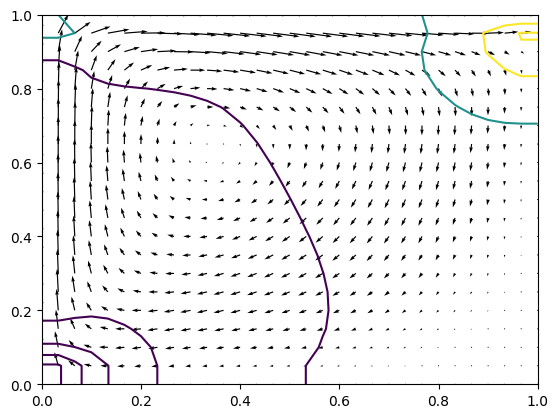

In [6]:
from matplotlib import cm

norm = cm.colors.Normalize(vmax=abs(u_tilde_next).max(), vmin=-abs(u_tilde_next).max())

plt.contour(X, Y, p_field_previous, norm=norm)
plt.quiver(X, Y, u_field_previous, v_field_previous)
print()